In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

import jax
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer


from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.datasets.classification.cifar10 import Cifar10

import equinox as eqx
import jax.tree_util as jtu
import optax
import jax.numpy as jnp


## Importing the dataset (CIFAR)

In [2]:
data = Cifar10(
    batch_size=32,
    linear_projection=None,
    label_mode="pm1",
    x_transform="identity",
)

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)

data.build(key=data_key)

Array([2566685366, 2716172981], dtype=uint32)

In [3]:
x, y = next(iter(data))
print(f"Data shape: x={x.shape}, y={y.shape}")
print(f"Expected: x=(batch, 32, 32, 3), got x={x.shape}")

# If flattened, reshape it back
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
    print(f"Reshaped x to: {x.shape}")

x = (x - x.mean()) / x.std()

Data shape: x=(32, 3072), y=(32, 10)
Expected: x=(batch, 32, 32, 3), got x=(32, 3072)
Reshaped x to: (32, 32, 32, 3)


## Build model 

In [4]:
def build_conv_model(
    seed: int,
    in_channels: int = 3,
    spatial_size: int = 32,
    n_channels: int = 64,
    num_labels: int = 10,
    input_kernel_size: int = 7,
    recur_kernel_size: int = 7,
    threshold_conv: float = 1.7,
    threshold_fc: float = 1.7,
    threshold_out: float = 1.7,
    threshold_back: float = 0.0,
    j_d_conv: float = 0.9,
    j_d_fc: float = 0.9,
    strength_in: float = 1.0,
    strength_pool: float = 1.0,
    strength_unpool: float = 1.0,
    strength_wout: float = 1.0,
    strength_wback: float = 1.0,
    lr_conv: float = 1.0,
    weight_decay_conv: float = 0.0,
    mask_prob: float = 0.0,
    field_momentum: float = 0.0
) -> tuple[SequentialState, SequentialOrchestrator]:

    keys = jax.random.split(jax.random.key(seed), 5)

    S = spatial_size

    layer_map = LayerMap.from_dict({
        1: {
            0: Conv2D(
                in_channels=in_channels,
                out_channels=n_channels,
                kernel_size=input_kernel_size,
                threshold=threshold_conv,
                strength=strength_in,
                key=keys[0],
                padding_mode="constant",
            ),
            1: Conv2DRecurrentDiscrete(
                channels=n_channels,
                kernel_size=recur_kernel_size,
                groups=n_channels,
                j_d=j_d_conv,
                threshold=threshold_conv,
                padding_mode="constant",
                key=keys[1],
                lr=lr_conv,
                weight_decay=weight_decay_conv,
            ),
            2: GlobalUnpooling(strength=strength_unpool, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=strength_pool, axis=(1, 2)),
            2: RecurrentDiscrete(
                features=n_channels,
                j_d=j_d_fc,
                threshold=threshold_fc,
                key=keys[2],
            ),
            3: FrozenRescaledFullyConnected(
                in_features=num_labels,
                out_features=n_channels,
                strength=strength_wback,
                threshold=threshold_back,
                key=keys[3],
            ),
        },
        3: {
            2: FullyConnected(
                in_features=n_channels,
                out_features=num_labels,
                strength=strength_wout,
                threshold=threshold_out,
                key=keys[4],
            ),
            3: OutputLayer(),
        },
    })

    state = SequentialState([
        (S, S, in_channels),
        (S, S, n_channels),
        (n_channels,),
        (num_labels,),
    ])
    orchestrator = SequentialOrchestrator(layers=layer_map, field_momentum=field_momentum, mask_prob=mask_prob)

    return state, orchestrator

## Parameter count

In [5]:
# ── Count parameters ───────────────────────────────────────────────────
def count_parameters(orchestrator: SequentialOrchestrator) -> dict:
    """Count trainable (inexact) parameters per module and in total."""
    params = eqx.filter(orchestrator, eqx.is_inexact_array)
    leaves = jtu.tree_leaves(params)

    total = sum(p.size for p in leaves)

    # Per-module breakdown
    modules = {
        "Conv2D (W_in)":               orchestrator.lmap[1][0],
        "Conv2DRecurrentDiscrete (J_conv)": orchestrator.lmap[1][1],
        "GlobalUnpooling":             orchestrator.lmap[1][2],
        "GlobalMajorityPooling":       orchestrator.lmap[2][1],
        "RecurrentDiscrete (J_fc)":    orchestrator.lmap[2][2],
        "FrozenRescaledFC (W_back)":   orchestrator.lmap[2][3],
        "FullyConnected (W_out)":      orchestrator.lmap[3][2],
        "OutputLayer":                 orchestrator.lmap[3][3],
    }

    breakdown = {}
    for name, mod in modules.items():
        mod_params = eqx.filter(mod, eqx.is_inexact_array)
        mod_leaves = jtu.tree_leaves(mod_params)
        count = sum(p.size for p in mod_leaves)
        breakdown[name] = count

    return {"total": total, "breakdown": breakdown}


# Build a default model just to count params
_st, _orch = build_conv_model(seed=0)
param_info = count_parameters(_orch)

print(f"{'Module':<40} {'Parameters':>12}  {'Share':>7}")
print("-" * 63)
for name, count in param_info["breakdown"].items():
    share = 100 * count / param_info["total"]
    print(f"{name:<40} {count:>12,}  {share:>6.1f}%")
print("-" * 63)
print(f"{'TOTAL':<40} {param_info['total']:>12,}  {'100.0%':>7}")


Module                                     Parameters    Share
---------------------------------------------------------------
Conv2D (W_in)                                   9,411    37.0%
Conv2DRecurrentDiscrete (J_conv)                6,276    24.7%
GlobalUnpooling                                     1     0.0%
GlobalMajorityPooling                               1     0.0%
RecurrentDiscrete (J_fc)                        8,323    32.7%
FrozenRescaledFC (W_back)                         770     3.0%
FullyConnected (W_out)                            662     2.6%
OutputLayer                                         0     0.0%
---------------------------------------------------------------
TOTAL                                          25,444   100.0%


## Run dynamics 

In [6]:
def run_dynamics(
    orchestrator: SequentialOrchestrator,
    state: SequentialState,
    rng,
    n_warmup: int = 1,
    n_clamped: int = 5,
    n_free: int = 5,
) -> tuple[SequentialState, list[SequentialState]]:

    history = []

    for _ in range(n_warmup):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)

    for _ in range(n_clamped):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="all")
        history.append(state)

    for _ in range(n_free):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)

    return state, history

## Weight update

In [7]:
def build_optimizer(
    orchestrator: SequentialOrchestrator,
    lr_w_in: float = 0.1,
    lr_j_conv: float = 0.05,
    lr_j_fc: float = 0.05,
    lr_w_out: float = 0.1,
    trainable_overrides: dict[tuple[int, int], str] | None = None,
) -> tuple[optax.GradientTransformation, optax.OptState]:

    if trainable_overrides is None:
        trainable_overrides = {
            (1, 0): "w_in",
            (1, 1): "j_conv",
            (2, 2): "j_fc",
            (3, 2): "w_out",
        }

    # Build label tree: every leaf starts as "default" (frozen, lr=0)
    params, _ = eqx.partition(orchestrator, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)

    def like(tree, value: str):
        return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

    for (i, j), label in trainable_overrides.items():
        labels = eqx.tree_at(
            lambda m, _i=i, _j=j: m.lmap[_i][_j],
            labels,
            replace=like(params.lmap[i][j], label),
        )

    # Map each label → its SGD optimizer
    lr_map = {
        "w_in":  lr_w_in,
        "j_conv": lr_j_conv,
        "j_fc":  lr_j_fc,
        "w_out": lr_w_out,
    }
    transforms = {"default": optax.sgd(learning_rate=0.0)}
    transforms.update({lbl: optax.sgd(learning_rate=lr) for lbl, lr in lr_map.items()})

    optimizer = optax.multi_transform(transforms, labels)
    opt_state = optimizer.init(eqx.filter(orchestrator, eqx.is_inexact_array))

    return optimizer, opt_state

In [8]:
def apply_update(
    orchestrator: SequentialOrchestrator,
    state: SequentialState,
    rng,
    optimizer: optax.GradientTransformation,
    opt_state: optax.OptState,
) -> tuple[SequentialOrchestrator, optax.OptState]:
    """Compute the backward (Hebbian) grads and apply one weight update.

    Parameters
    ----------
    orchestrator:
        Current model.
    state:
        The ``SequentialState`` **after** dynamics have converged
        (i.e. the output of ``run_dynamics``).
    rng:
        A JAX PRNG key.
    optimizer:
        The optax optimizer returned by ``build_optimizer``.
    opt_state:
        Current optimizer state.

    Returns
    -------
    new_orchestrator:
        Updated model with new weights.
    new_opt_state:
        Updated optimizer state.
    """
    # Step 1: backward pass → raw Hebbian grads
    grads = orchestrator.backward(state, rng=rng)

    # Step 2: optimizer scales grads by per-module learning rates
    grads_filtered = eqx.filter(grads, eqx.is_inexact_array)
    params_filtered = eqx.filter(orchestrator, eqx.is_inexact_array)
    updates, new_opt_state = optimizer.update(
        grads_filtered, opt_state, params=params_filtered
    )

    # Step 3: apply updates → new orchestrator
    new_orchestrator = eqx.apply_updates(orchestrator, updates)

    return new_orchestrator, new_opt_state

## Helper

In [9]:
# =====================================================================
# Helper functions — reusable analysis tools
# =====================================================================

def extract_layer(history, layer_idx):
    """Return array (n_steps, batch, *spatial) for a given layer."""
    return [np.array(h.states[layer_idx]) for h in history]


def flatten_layer(activations):
    """Flatten spatial dims → list of (batch, features) arrays."""
    return [a.reshape(a.shape[0], -1) for a in activations]


# --- Cosine similarity matrix ---

def compute_cosine_similarity_matrix(history, layer_idx=1, batch_idx=None):
    """Pairwise cosine similarity between states at all time-step pairs."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    mat = np.zeros((T, T))
    for i in range(T):
        for j in range(i, T):
            if batch_idx is not None:
                sim = cosine_similarity([acts[i][batch_idx]], [acts[j][batch_idx]])[0, 0]
            else:
                sims = [cosine_similarity([acts[i][b]], [acts[j][b]])[0, 0]
                        for b in range(acts[i].shape[0])]
                sim = np.nanmean(sims)
            mat[i, j] = mat[j, i] = sim
    return mat


# --- Neuron flips ---

def compute_neuron_flips(history, layer_idx=1, percentage=True):
    """Fraction (or count) of neurons that flip sign between consecutive steps."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    flips = np.zeros(T - 1)
    for t in range(T - 1):
        diff = (acts[t] != acts[t + 1]).astype(float)  # (batch, features)
        if percentage:
            flips[t] = diff.mean() * 100  # average over batch & features
        else:
            flips[t] = diff.mean(axis=1).sum()  # average per sample, sum over batch
    return flips


# --- Clamped-free distance ---

def clamped_free_distance(history, layer_idx, n_warmup=1, n_clamped=5):
    """Cosine distance between end-of-clamped and end-of-free activations.

    Returns scalar = 1 − mean_batch( cos_sim(clamped_end, free_end) ).
    """
    acts = flatten_layer(extract_layer(history, layer_idx))
    idx_clamped_end = n_warmup + n_clamped - 1
    idx_free_end = len(acts) - 1
    sims = [cosine_similarity([acts[idx_clamped_end][b]], [acts[idx_free_end][b]])[0, 0]
            for b in range(acts[idx_clamped_end].shape[0])]
    return 1.0 - np.nanmean(sims)


# --- W_back overlap ---

def compute_wback_overlap(history, wback_module, layer_idx=2, output_idx=3):
    """Cosine similarity between wback(y) and layer_idx activation at each step."""
    T = len(history)
    overlaps = np.zeros(T)
    for t in range(T):
        output = np.array(history[t].states[output_idx])     # (batch, 10)
        projected = np.array(wback_module(output))            # (batch, N_CH)
        layer_act = np.array(history[t].states[layer_idx])    # (batch, N_CH)
        sims = []
        for b in range(layer_act.shape[0]):
            p, l = projected[b], layer_act[b]
            norm = np.linalg.norm(p) * np.linalg.norm(l) + 1e-8
            sims.append(np.dot(p, l) / norm)
        overlaps[t] = np.mean(sims)
    return overlaps


# --- Free-phase accuracy + output label alignment ---

def compute_free_metrics(orchestrator, state_final, y_true, rng):
    """Accuracy and output label alignment after the free phase via predict().
    """
    rng, pred_rng = jax.random.split(rng)
    pred_state, _ = orchestrator.predict(state_final, pred_rng)
    predicted  = np.array(pred_state.states[-1])        # (batch, 10)
    y_true_np  = np.array(y_true)                       # (batch, 10), ±1

    true_cls   = np.argmax(y_true_np, axis=-1)          # (batch,)
    pred_cls   = np.argmax(predicted, axis=-1)           # (batch,)
    accuracy   = float(np.mean(pred_cls == true_cls))

    # sign(predicted) ∈ {-1, 0, +1}; element-wise product with ±1 label
    alignment  = float(np.mean(np.sign(predicted) * y_true_np))

    return accuracy, alignment, rng


# Keep old single-return wrapper for backward compatibility with earlier cells
def compute_free_accuracy(orchestrator, state_final, y_true, rng):
    acc, _, rng = compute_free_metrics(orchestrator, state_final, y_true, rng)
    return acc, rng


# --- Soft margin ---

def compute_soft_margin(orchestrator, state_final, y_true, rng):
    """Soft margin = logit[true_class] - max(logit[wrong_classes]), averaged over batch.

    Parameters
    ----------
    orchestrator : SequentialOrchestrator
    state_final : SequentialState  (after dynamics)
    y_true : array (batch, num_classes), ±1 labels
    rng : JAX key

    Returns
    -------
    margin : float   (positive → correct, larger → more confident)
    rng    : updated key
    """
    rng, pred_rng = jax.random.split(rng)
    pred_state, _ = orchestrator.predict(state_final, pred_rng)
    logits    = np.array(pred_state.states[-1])          # (batch, num_classes)
    y_true_np = np.array(y_true)                         # (batch, num_classes), ±1
    true_cls  = np.argmax(y_true_np, axis=-1)            # (batch,)

    margins = []
    for b in range(logits.shape[0]):
        tc = int(true_cls[b])
        correct_logit = logits[b, tc]
        wrong_logits  = np.concatenate([logits[b, :tc], logits[b, tc+1:]])
        margins.append(float(correct_logit - wrong_logits.max()))

    return float(np.mean(margins)), rng


## Catastrophic Forgetting: image A → image B

**Protocol:**
1. Fix a good `(threshold, lr)` pair (chosen from the sweep above).
2. Train on **image A** for `N_LEARN_A` updates until it is memorized (soft margin > 0).
3. Switch to **image B** and keep updating weights on B for `N_LEARN_B` steps.
4. At every step of phase 2, evaluate the soft margin on **image A** (without clamping).

**Question:** after how many updates on B does the model forget A (margin\_A drops below 0)?


In [11]:
MOMENTUM     = 0.5
MASK_PROB    = 0.2
N_UPDATES_MAX = 100
N_WARMUP, N_CLAMPED, N_FREE = 1, 5, 5


In [12]:
def run_memorization(x_data, y_data, threshold, lr, seed=0, n_updates=None):
    """Train on a fixed single image; record soft margin at every step.

    Parameters
    ----------
    n_updates : int, optional
        Number of weight-update steps.  Defaults to the global ``N_UPDATES_MAX``.

    Returns
    -------
    margin_history : list[float]
        Soft margin at update steps 0, 1, …, n_updates.
    """
    if n_updates is None:
        n_updates = N_UPDATES_MAX

    st, orch = build_conv_model(
        seed=seed,
        threshold_conv=threshold,
        threshold_fc=threshold,
        threshold_out=threshold,
        mask_prob=MASK_PROB,
        field_momentum=MOMENTUM,
    )
    opt, opt_st = build_optimizer(
        orch,
        lr_w_in=lr,
        lr_j_conv=lr,
        lr_j_fc=lr,
        lr_w_out=lr,
    )

    rng = jax.random.PRNGKey(42)
    margin_history = []

    for step in range(n_updates + 1):
        s0 = st.init(x_data, y_data)
        rng, dyn_rng = jax.random.split(rng)
        state_final, _ = run_dynamics(
            orch, s0, rng=dyn_rng,
            n_warmup=N_WARMUP, n_clamped=N_CLAMPED, n_free=N_FREE,
        )

        margin, rng = compute_soft_margin(orch, state_final, y_data, rng)
        margin_history.append(margin)

        if step < n_updates:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_st = apply_update(
                orch, state_final, rng=upd_rng, optimizer=opt, opt_state=opt_st
            )

    return margin_history


In [13]:
# ── Fixed hyperparams (chosen from sweep) ──────────────────────────────
FORGET_THRESHOLD = 2.5
FORGET_LR        = 0.2
N_LEARN_A        = 10
N_LEARN_B        = 10

# ── Averaging configs ──────────────────────────────────────────────────
N_FORGET_SEEDS = 3          # for seed averaging: fixed pair, different seeds
N_FORGET_PAIRS = 3          # for pair averaging: fixed seed, different pairs

# Fixed pair used for seed-averaging experiment
FIXED_PAIR_A = (0, 1)       # (idx_a, idx_b) into x, y

# Fixed seed used for pair-averaging experiment
FIXED_SEED = 0

# Image pairs used for pair-averaging experiment
IMAGE_PAIRS = [(0, 1), (2, 3), (4, 5)]

print("Fixed pair (used for seed averaging):")
ia, ib = FIXED_PAIR_A
print(f"  ({ia},{ib})  →  class A={int(np.array(y[ia:ia+1]).argmax())}, "
      f"class B={int(np.array(y[ib:ib+1]).argmax())}")

print(f"\nImage pairs (used for pair averaging, fixed seed={FIXED_SEED}):")
for idx_a, idx_b in IMAGE_PAIRS:
    cls_a = int(np.array(y[idx_a:idx_a+1]).argmax())
    cls_b = int(np.array(y[idx_b:idx_b+1]).argmax())
    print(f"  ({idx_a},{idx_b})  →  class A={cls_a}, class B={cls_b}")


# ── Core experiment ────────────────────────────────────────────────────

def run_forgetting_experiment(
    x_a, y_a, x_b, y_b,
    threshold=FORGET_THRESHOLD,
    lr=FORGET_LR,
    n_learn_a=N_LEARN_A,
    n_learn_b=N_LEARN_B,
    seed=0,
):
    """Train on A, then switch to B; track soft margins on both images at every step."""
    st, orch = build_conv_model(
        seed=seed,
        threshold_conv=threshold,
        threshold_fc=threshold,
        threshold_out=threshold,
        mask_prob=MASK_PROB,
        field_momentum=MOMENTUM,
    )
    opt, opt_st = build_optimizer(
        orch, lr_w_in=lr, lr_j_conv=lr, lr_j_fc=lr, lr_w_out=lr,
    )
    rng = jax.random.PRNGKey(seed)

    # ── Phase A ─────────────────────────────────────────────────────────
    phase_a_margins = []
    for step in range(n_learn_a + 1):
        s0 = st.init(x_a, y_a)
        rng, dyn_rng = jax.random.split(rng)
        s_final, _ = run_dynamics(orch, s0, rng=dyn_rng,
                                  n_warmup=N_WARMUP, n_clamped=N_CLAMPED, n_free=N_FREE)
        m_a, rng = compute_soft_margin(orch, s_final, y_a, rng)
        phase_a_margins.append(m_a)
        if step < n_learn_a:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_st = apply_update(orch, s_final, rng=upd_rng,
                                        optimizer=opt, opt_state=opt_st)

    # ── Phase B ─────────────────────────────────────────────────────────
    phase_b_margins_A, phase_b_margins_B = [], []
    for step in range(n_learn_b + 1):
        s0_a = st.init(x_a, y_a)
        rng, dyn_rng = jax.random.split(rng)
        s_final_a, _ = run_dynamics(orch, s0_a, rng=dyn_rng,
                                    n_warmup=N_WARMUP, n_clamped=N_CLAMPED, n_free=N_FREE)
        m_a, rng = compute_soft_margin(orch, s_final_a, y_a, rng)
        phase_b_margins_A.append(m_a)

        s0_b = st.init(x_b, y_b)
        rng, dyn_rng = jax.random.split(rng)
        s_final_b, _ = run_dynamics(orch, s0_b, rng=dyn_rng,
                                    n_warmup=N_WARMUP, n_clamped=N_CLAMPED, n_free=N_FREE)
        m_b, rng = compute_soft_margin(orch, s_final_b, y_b, rng)
        phase_b_margins_B.append(m_b)

        if step < n_learn_b:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_st = apply_update(orch, s_final_b, rng=upd_rng,
                                        optimizer=opt, opt_state=opt_st)

    return phase_a_margins, phase_b_margins_A, phase_b_margins_B


def _aggregate(runs):
    all_phaseA = [r[0] for r in runs]
    all_B_A    = [r[1] for r in runs]
    all_B_B    = [r[2] for r in runs]
    means = {"phaseA": np.mean(all_phaseA, axis=0),
             "B_A":    np.mean(all_B_A,    axis=0),
             "B_B":    np.mean(all_B_B,    axis=0)}
    stds  = {"phaseA": np.std(all_phaseA, axis=0),
             "B_A":    np.std(all_B_A,    axis=0),
             "B_B":    np.std(all_B_B,    axis=0)}
    return means, stds


def run_forgetting_averaged_seeds(idx_a, idx_b, x_data, y_data, threshold, lr,
                                   n_learn_a=N_LEARN_A, n_learn_b=N_LEARN_B,
                                   n_seeds=N_FORGET_SEEDS):
    """Average over `n_seeds` random seeds — same image pair each time."""
    xa, ya = x_data[idx_a:idx_a+1], y_data[idx_a:idx_a+1]
    xb, yb = x_data[idx_b:idx_b+1], y_data[idx_b:idx_b+1]
    runs = [run_forgetting_experiment(xa, ya, xb, yb,
                                      threshold=threshold, lr=lr,
                                      n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                                      seed=s)
            for s in range(n_seeds)]
    return _aggregate(runs)


def run_forgetting_averaged_pairs(image_pairs, x_data, y_data, threshold, lr,
                                   n_learn_a=N_LEARN_A, n_learn_b=N_LEARN_B,
                                   seed=FIXED_SEED):
    """Average over `image_pairs` — same random seed each time."""
    runs = []
    for idx_a, idx_b in image_pairs:
        xa, ya = x_data[idx_a:idx_a+1], y_data[idx_a:idx_a+1]
        xb, yb = x_data[idx_b:idx_b+1], y_data[idx_b:idx_b+1]
        runs.append(run_forgetting_experiment(xa, ya, xb, yb,
                                              threshold=threshold, lr=lr,
                                              n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                                              seed=seed))
    return _aggregate(runs)


# ── Run both averaging strategies ─────────────────────────────────────
print(f"\n[1] Seed averaging — pair {FIXED_PAIR_A}, {N_FORGET_SEEDS} seeds ...")
means_seeds, stds_seeds = run_forgetting_averaged_seeds(
    *FIXED_PAIR_A, x, y, threshold=FORGET_THRESHOLD, lr=FORGET_LR,
)
print(f"    margin_A end of phase A = {means_seeds['phaseA'][-1]:.3f} ± {stds_seeds['phaseA'][-1]:.3f}")

print(f"\n[2] Pair averaging — seed={FIXED_SEED}, {N_FORGET_PAIRS} pairs ...")
means_pairs, stds_pairs = run_forgetting_averaged_pairs(
    IMAGE_PAIRS, x, y, threshold=FORGET_THRESHOLD, lr=FORGET_LR,
)
print(f"    margin_A end of phase A = {means_pairs['phaseA'][-1]:.3f} ± {stds_pairs['phaseA'][-1]:.3f}")


Fixed pair (used for seed averaging):
  (0,1)  →  class A=3, class B=2

Image pairs (used for pair averaging, fixed seed=0):
  (0,1)  →  class A=3, class B=2
  (2,3)  →  class A=5, class B=7
  (4,5)  →  class A=2, class B=8

[1] Seed averaging — pair (0, 1), 3 seeds ...
    margin_A end of phase A = 2.955 ± 0.287

[2] Pair averaging — seed=0, 3 pairs ...
    margin_A end of phase A = 2.881 ± 0.071


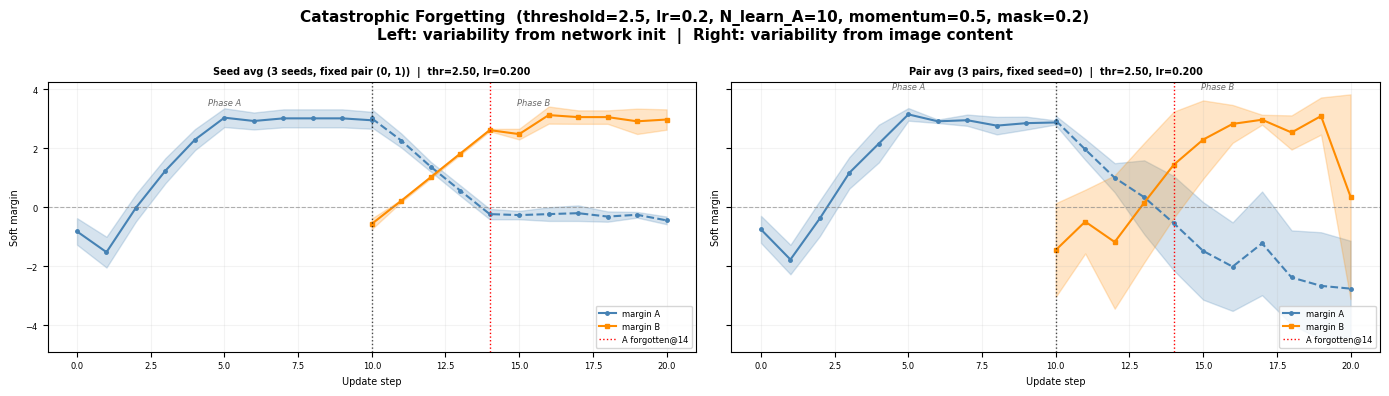

In [14]:
def plot_forgetting(means, stds, n_learn_a=N_LEARN_A,
                    threshold=FORGET_THRESHOLD, lr=FORGET_LR,
                    ax=None, title_prefix=""):
    """Single-panel forgetting plot: phase A and phase B concatenated on one axis."""
    standalone = (ax is None)
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 3.5))

    n_a = len(means["phaseA"])
    n_b = len(means["B_A"])

    steps_a = np.arange(n_a)
    steps_b = np.arange(n_a - 1, n_a - 1 + n_b)

    ax.plot(steps_a, means["phaseA"], color="steelblue", linewidth=1.5,
            marker="o", ms=2.5, label="margin A")
    ax.fill_between(steps_a,
                    means["phaseA"] - stds["phaseA"],
                    means["phaseA"] + stds["phaseA"],
                    color="steelblue", alpha=0.22)

    ax.plot(steps_b, means["B_A"], color="steelblue", linewidth=1.5,
            marker="o", ms=2.5, linestyle="--")
    ax.fill_between(steps_b,
                    means["B_A"] - stds["B_A"],
                    means["B_A"] + stds["B_A"],
                    color="steelblue", alpha=0.22)

    ax.plot(steps_b, means["B_B"], color="darkorange", linewidth=1.5,
            marker="s", ms=2.5, label="margin B")
    ax.fill_between(steps_b,
                    means["B_B"] - stds["B_B"],
                    means["B_B"] + stds["B_B"],
                    color="darkorange", alpha=0.22)

    ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.6)

    boundary = n_a - 1
    ax.axvline(boundary, color="black", lw=1.0, ls=":", alpha=0.7)

    forgotten_at = next((s for s, mv in zip(steps_b, means["B_A"]) if mv < 0), None)
    if forgotten_at is not None:
        ax.axvline(forgotten_at, color="red", lw=1.0, ls=":",
                   label=f"A forgotten@{forgotten_at}")

    ax.text(boundary / 2, ax.get_ylim()[1], "Phase A",
            ha="center", va="top", fontsize=6, color="dimgray", style="italic")
    ax.text(boundary + n_b / 2, ax.get_ylim()[1], "Phase B",
            ha="center", va="top", fontsize=6, color="dimgray", style="italic")

    ax.set_xlabel("Update step", fontsize=7)
    ax.set_ylabel("Soft margin", fontsize=7)
    ax.set_title(f"{title_prefix}thr={threshold:.2f}, lr={lr:.3f}",
                 fontsize=7, fontweight="bold")
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.15)
    ax.legend(fontsize=6, loc="lower right")

    if standalone:
        plt.tight_layout()
        plt.show()


# ── Side-by-side comparison: seed averaging vs pair averaging ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

plot_forgetting(means_seeds, stds_seeds, ax=axes[0],
                title_prefix=f"Seed avg ({N_FORGET_SEEDS} seeds, fixed pair {FIXED_PAIR_A})  |  ")
plot_forgetting(means_pairs, stds_pairs, ax=axes[1],
                title_prefix=f"Pair avg ({N_FORGET_PAIRS} pairs, fixed seed={FIXED_SEED})  |  ")

fig.suptitle(
    f"Catastrophic Forgetting  (threshold={FORGET_THRESHOLD}, lr={FORGET_LR}, "
    f"N_learn_A={N_LEARN_A}, momentum={MOMENTUM}, mask={MASK_PROB})\n"
    "Left: variability from network init  |  Right: variability from image content",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()


## Forgetting Sweep (5 × 5 grid)

Same forgetting protocol swept over a 5×5 grid of `(threshold, lr)`.

For each cell two averages are computed and shown side-by-side:
- **Seed avg**: fixed image pair `FIXED_PAIR_A`, averaged over `N_FORGET_SEEDS` random seeds → measures sensitivity to weight initialisation
- **Pair avg**: fixed seed `FIXED_SEED`, averaged over `IMAGE_PAIRS` → measures sensitivity to image content


In [15]:
# ── Forgetting sweep grid ──────────────────────────────────────────────
FORGET_THRESHOLDS_SWEEP = [0.5, 1.0, 1.7, 2.5, 3.5]
FORGET_LRS_SWEEP        = [0.02, 0.05, 0.1, 0.2, 0.5]
n_combos = len(FORGET_THRESHOLDS_SWEEP) * len(FORGET_LRS_SWEEP)

print(f"Forgetting sweep: {len(FORGET_THRESHOLDS_SWEEP)} thresholds × {len(FORGET_LRS_SWEEP)} LRs = {n_combos} combos")
print(f"  each combo: seed avg ({N_FORGET_SEEDS} seeds, pair {FIXED_PAIR_A}) + "
      f"pair avg ({N_FORGET_PAIRS} pairs, seed={FIXED_SEED})")

# forget_results_seeds[(thr, lr)] = (means, stds)  — seed averaging
# forget_results_pairs[(thr, lr)] = (means, stds)  — pair averaging
forget_results_seeds = {}
forget_results_pairs = {}

for thr in FORGET_THRESHOLDS_SWEEP:
    for lr_val in FORGET_LRS_SWEEP:
        forget_results_seeds[(thr, lr_val)] = run_forgetting_averaged_seeds(
            *FIXED_PAIR_A, x, y, threshold=thr, lr=lr_val,
        )
        forget_results_pairs[(thr, lr_val)] = run_forgetting_averaged_pairs(
            IMAGE_PAIRS, x, y, threshold=thr, lr=lr_val,
        )
    print(f"  thr={thr:.2f} done")

print("\nForgetting sweep complete.")


Forgetting sweep: 5 thresholds × 5 LRs = 25 combos
  each combo: seed avg (3 seeds, pair (0, 1)) + pair avg (3 pairs, seed=0)
  thr=0.50 done
  thr=1.00 done
  thr=1.70 done
  thr=2.50 done
  thr=3.50 done

Forgetting sweep complete.


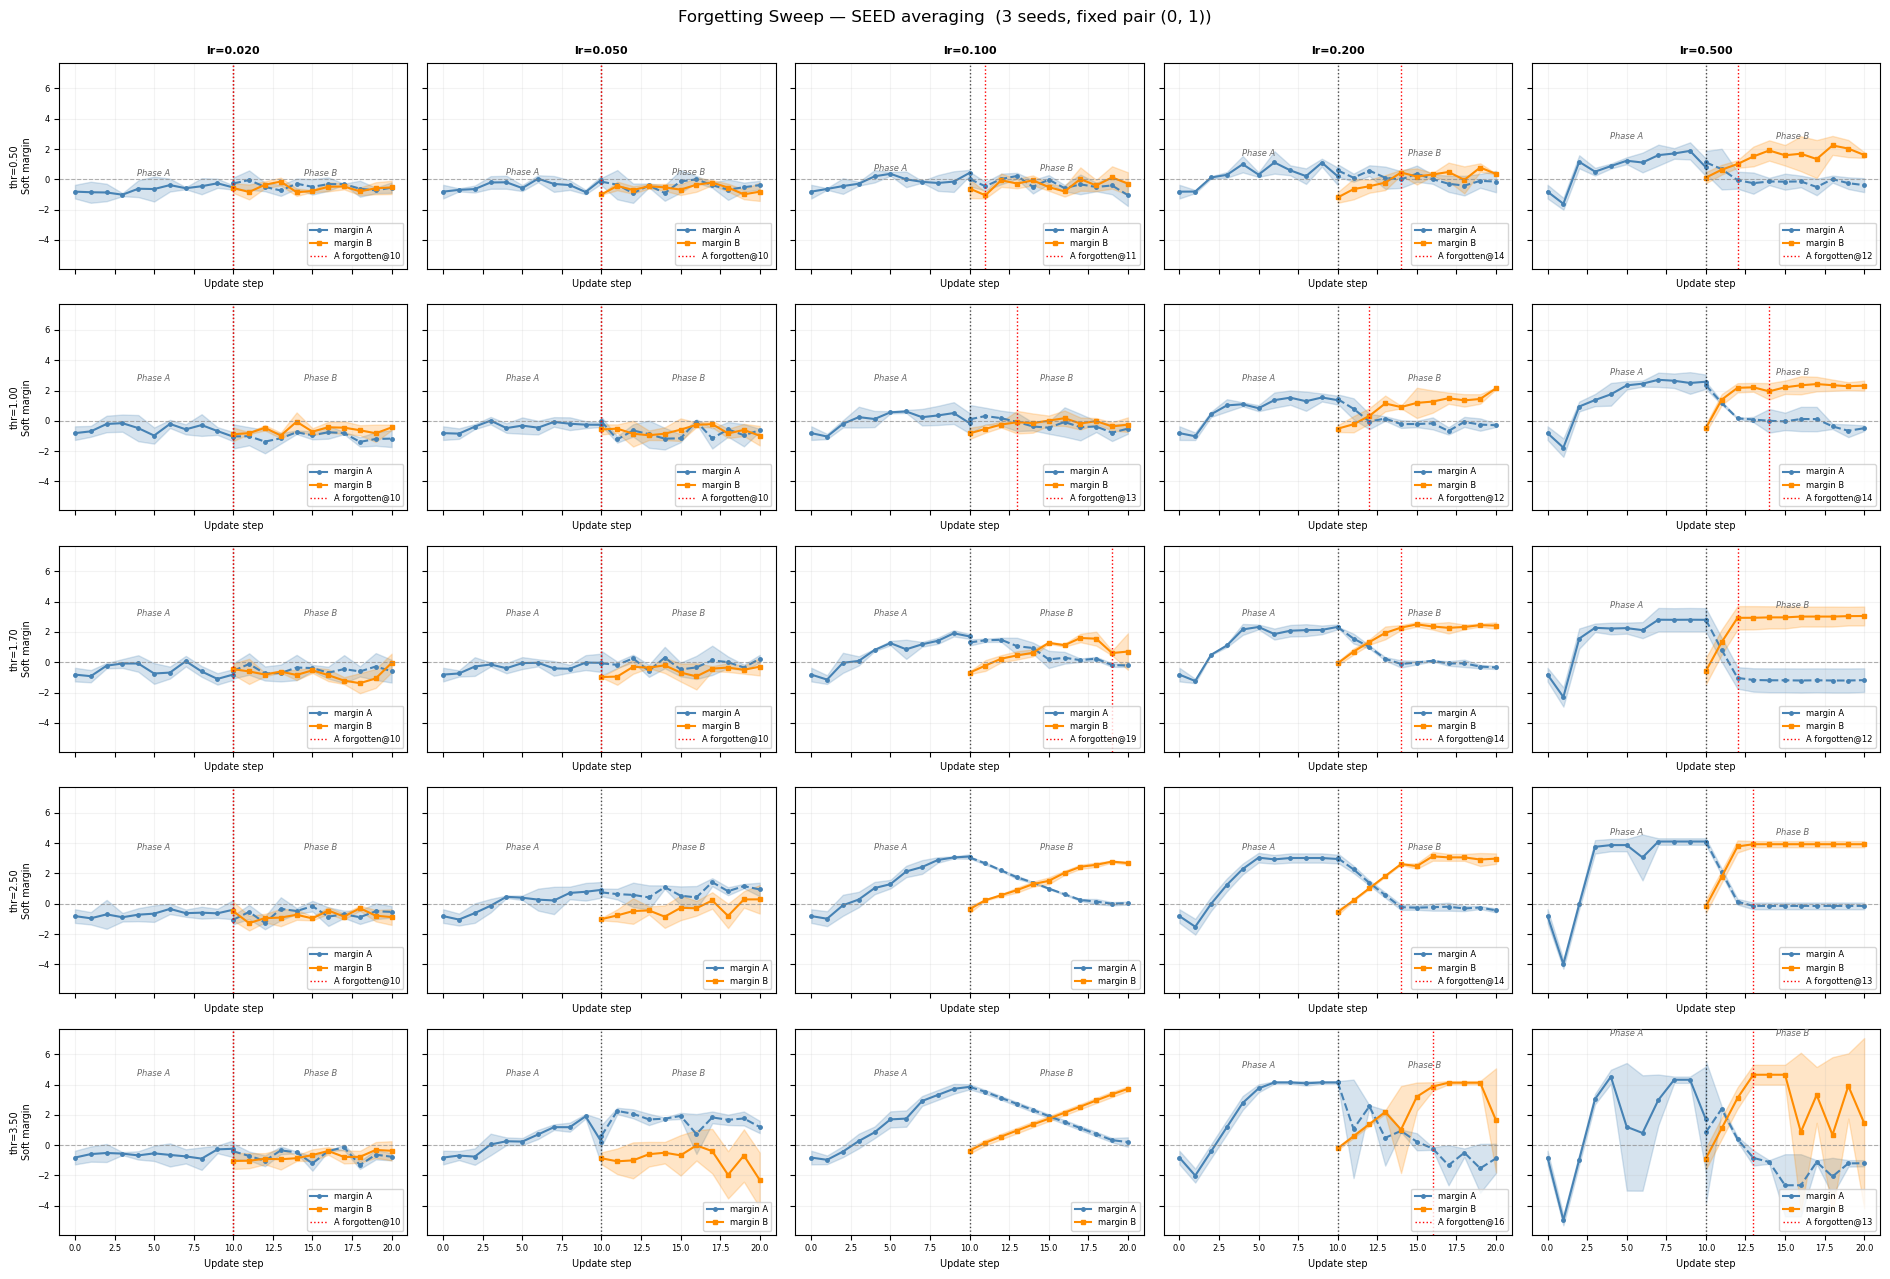

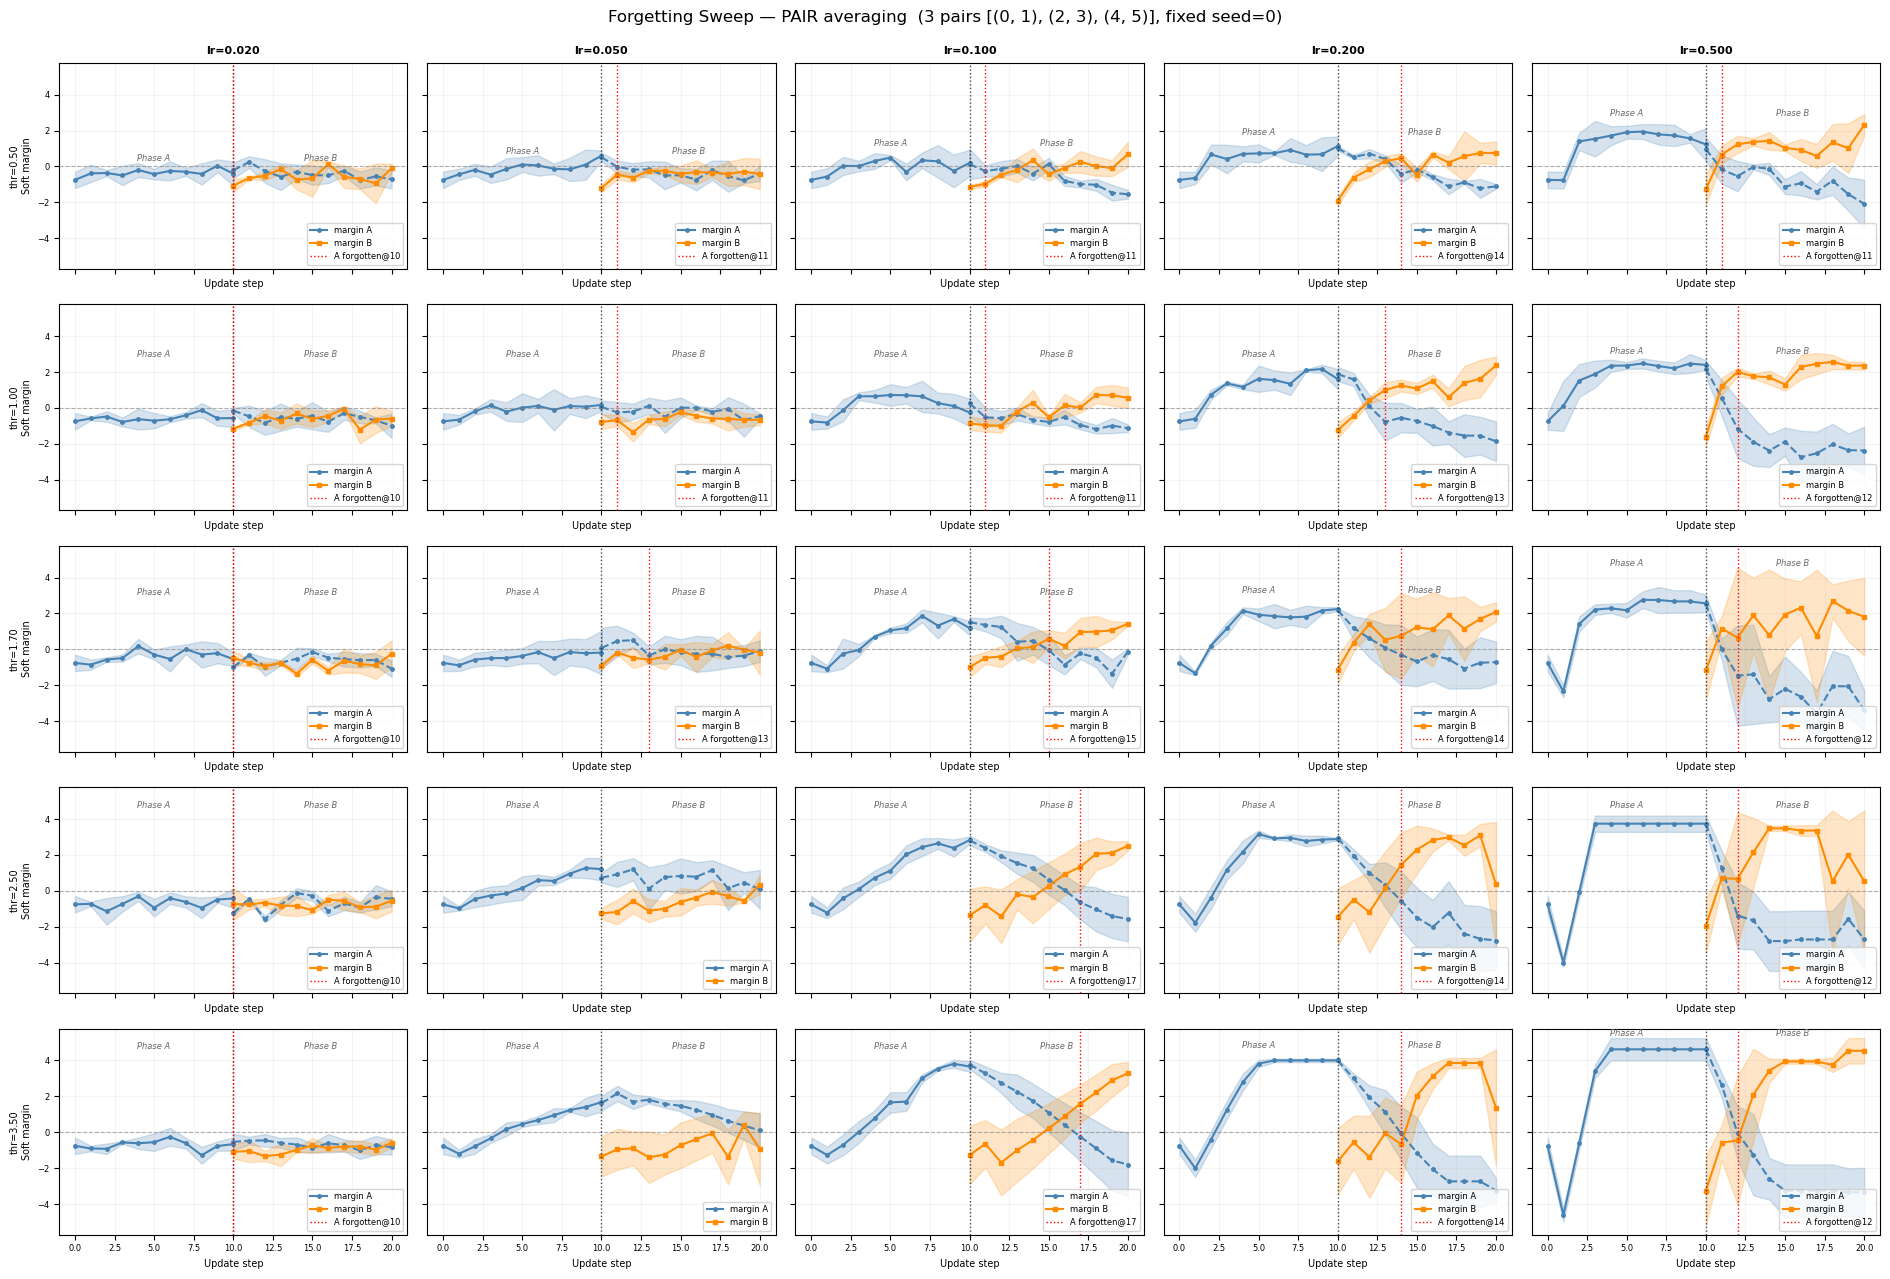

In [31]:
def plot_forgetting_grid(forget_results, thresholds, lrs, grid_title,
                          n_learn_a=N_LEARN_A, shared_y=True):
    """5×5 grid of forgetting plots, optionally with shared y-axis."""
    n_thr, n_lr = len(thresholds), len(lrs)
    sharey = "all" if shared_y else "none"

    fig, axes = plt.subplots(
        n_thr, n_lr,
        figsize=(3.8 * n_lr, 2.6 * n_thr),
        sharex=True, sharey=sharey,
    )

    for r, thr in enumerate(thresholds):
        for c, lr_val in enumerate(lrs):
            ax = axes[r, c]
            means, stds = forget_results[(thr, lr_val)]
            plot_forgetting(means, stds, threshold=thr, lr=lr_val, ax=ax)

            if r == 0:
                ax.set_title(f"lr={lr_val:.3f}", fontsize=8, fontweight="bold")
            else:
                ax.set_title("")

            if c == 0:
                ax.set_ylabel(f"thr={thr:.2f}\n{ax.get_ylabel()}", fontsize=7)
            else:
                ax.set_ylabel("")

    fig.suptitle(
        f"{grid_title}\n"
    )
    plt.tight_layout()
    plt.show()


# ── Seed averaging grid ────────────────────────────────────────────────
plot_forgetting_grid(
    forget_results_seeds,
    FORGET_THRESHOLDS_SWEEP, FORGET_LRS_SWEEP,
    grid_title=(f"Forgetting Sweep — SEED averaging  "
                f"({N_FORGET_SEEDS} seeds, fixed pair {FIXED_PAIR_A})"),
)

# ── Pair averaging grid ────────────────────────────────────────────────
plot_forgetting_grid(
    forget_results_pairs,
    FORGET_THRESHOLDS_SWEEP, FORGET_LRS_SWEEP,
    grid_title=(f"Forgetting Sweep — PAIR averaging  "
                f"({N_FORGET_PAIRS} pairs {IMAGE_PAIRS}, fixed seed={FIXED_SEED})"),
)


## Coexistence Score $S$

A run is scored only if both basic checks pass:
- $g_1 = 1$ if pattern A was stably learned at the end of phase A (final margin\_A $> 0$)
- $g_2 = 1$ if pattern B was learned at least once during phase B (some margin\_B $> 0$)

The two coexistence quantities measure phase-B steps where **both** margins are positive simultaneously:
- $C_{\text{frac}}$ — fraction of phase-B steps where both A and B are correct
- $C_{\text{max}}$ — longest *continuous* such block, normalised by phase-B length

$$S = g_1 \, g_2 \, \sqrt{C_{\text{frac}} \cdot C_{\text{max}}}$$

$S$ is high only when both memories coexist **often** and **continuously**.  
We compute $S$ per individual run (before averaging) so the score is not smoothed out by averaging trajectories.


In [18]:
def compute_coexistence_score(phase_a_margins, phase_b_margins_A, phase_b_margins_B):
    """Compute the coexistence score S for a single run.

    Parameters
    ----------
    phase_a_margins   : list[float]  — margin on A at each step of phase A
    phase_b_margins_A : list[float]  — margin on A at each step of phase B
    phase_b_margins_B : list[float]  — margin on B at each step of phase B

    Returns
    -------
    S        : float in [0, 1]
    g1, g2   : gate values (0 or 1)
    C_frac   : float in [0, 1]
    C_max    : float in [0, 1]
    """
    # Gate 1: was A stably learned? (positive margin at END of phase A)
    g1 = 1.0 if phase_a_margins[-1] > 0 else 0.0

    # Gate 2: was B ever learned during phase B?
    g2 = 1.0 if any(m > 0 for m in phase_b_margins_B) else 0.0

    if g1 == 0.0 or g2 == 0.0:
        return 0.0, g1, g2, 0.0, 0.0

    n_b = len(phase_b_margins_B)

    # Both margins positive simultaneously at each phase-B step
    coexist = [
        1 if (ma > 0 and mb > 0) else 0
        for ma, mb in zip(phase_b_margins_A, phase_b_margins_B)
    ]

    # C_frac: fraction of steps with coexistence
    C_frac = sum(coexist) / n_b

    # C_max: longest continuous coexistence block / n_b
    max_run, cur_run = 0, 0
    for c in coexist:
        if c:
            cur_run += 1
            max_run = max(max_run, cur_run)
        else:
            cur_run = 0
    C_max = max_run / n_b

    S = g1 * g2 * float(np.sqrt(C_frac * C_max))
    return S, g1, g2, C_frac, C_max


def run_coexistence_sweep_pairs(thresholds, lrs, image_pairs, x_data, y_data,
                                 seed=FIXED_SEED,
                                 n_learn_a=N_LEARN_A, n_learn_b=N_LEARN_B):
    """Sweep (threshold, lr) grid; for each cell average S over `image_pairs`."""
    scores = {}
    for thr in thresholds:
        for lr_val in lrs:
            run_scores = []
            for idx_a, idx_b in image_pairs:
                xa, ya = x_data[idx_a:idx_a+1], y_data[idx_a:idx_a+1]
                xb, yb = x_data[idx_b:idx_b+1], y_data[idx_b:idx_b+1]
                pa, pb_a, pb_b = run_forgetting_experiment(
                    xa, ya, xb, yb,
                    threshold=thr, lr=lr_val,
                    n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                    seed=seed,
                )
                S, *_ = compute_coexistence_score(pa, pb_a, pb_b)
                run_scores.append(S)
            scores[(thr, lr_val)] = float(np.mean(run_scores))
        print(f"  thr={thr:.2f} done")
    return scores



print(f"\n[Pair avg] Coexistence sweep — seed={FIXED_SEED}, {N_FORGET_PAIRS} pairs ...")
coex_scores_pairs = run_coexistence_sweep_pairs(
    FORGET_THRESHOLDS_SWEEP, FORGET_LRS_SWEEP,
    IMAGE_PAIRS, x, y,
)
print("\nDone.")



[Pair avg] Coexistence sweep — seed=0, 3 pairs ...
  thr=0.50 done
  thr=1.00 done
  thr=1.70 done
  thr=2.50 done
  thr=3.50 done

Done.


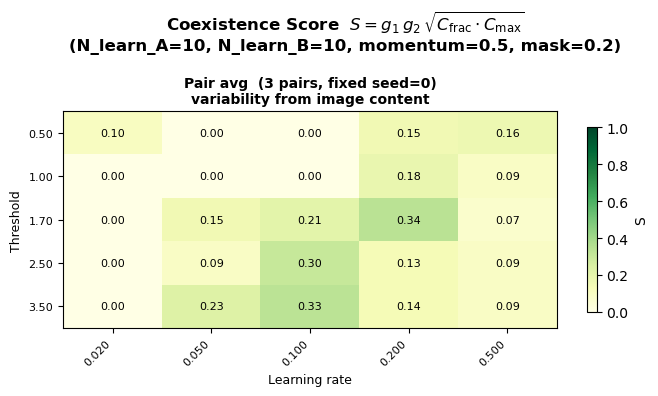

In [19]:
def plot_coexistence_heatmap(scores_pairs, thresholds, lrs):
    """Heatmap of the coexistence score S (pair-averaged).

    scores_pairs : dict  — keys (thr, lr), values float S in [0, 1]
    """
    n_thr, n_lr = len(thresholds), len(lrs)
    lr_labels  = [f"{l:.3f}" for l in lrs]
    thr_labels = [f"{t:.2f}" for t in thresholds]
    ann_fs = max(6, 9 - n_thr // 3)

    def _to_matrix(scores):
        mat = np.zeros((n_thr, n_lr))
        for r, thr in enumerate(thresholds):
            for c, lr_val in enumerate(lrs):
                mat[r, c] = scores[(thr, lr_val)]
        return mat

    mat_pairs = _to_matrix(scores_pairs)

    fig, ax = plt.subplots(figsize=(max(7, 1.2 * n_lr), max(4, 0.55 * n_thr)))

    im = ax.imshow(mat_pairs, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(n_lr))
    ax.set_xticklabels(lr_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n_thr))
    ax.set_yticklabels(thr_labels, fontsize=8)
    ax.set_xlabel("Learning rate", fontsize=9)
    ax.set_ylabel("Threshold", fontsize=9)
    ax.set_title(
        f"Pair avg  ({N_FORGET_PAIRS} pairs, fixed seed={FIXED_SEED})\n"
        f"variability from image content",
        fontsize=10, fontweight="bold",
    )
    for r in range(n_thr):
        for c in range(n_lr):
            val = mat_pairs[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=ann_fs,
                    color="black" if val < 0.6 else "white")
    plt.colorbar(im, ax=ax, shrink=0.85, label="S")

    fig.suptitle(
        r"Coexistence Score  $S = g_1\,g_2\,\sqrt{C_{\mathrm{frac}}\cdot C_{\mathrm{max}}}$"
        f"\n(N_learn_A={N_LEARN_A}, N_learn_B={N_LEARN_B}, "
        f"momentum={MOMENTUM}, mask={MASK_PROB})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


plot_coexistence_heatmap(
    coex_scores_pairs,
    FORGET_THRESHOLDS_SWEEP, FORGET_LRS_SWEEP,
)


[Pair avg] Coexistence step count sweep — seed=0, 3 pairs ...
  thr=0.50 done
  thr=1.00 done
  thr=1.70 done
  thr=2.50 done
  thr=3.50 done


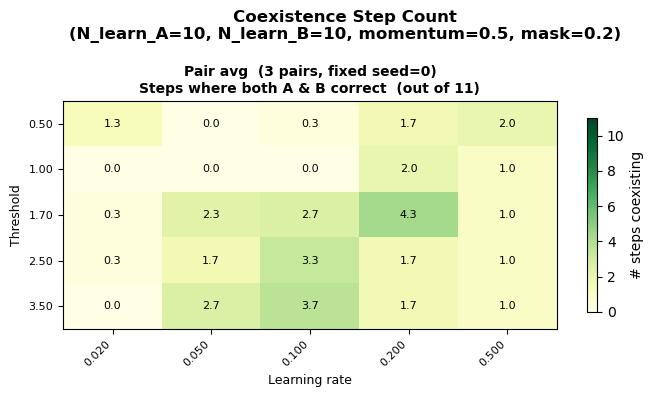

In [20]:
def run_coexistence_steps_sweep_pairs(thresholds, lrs, image_pairs, x_data, y_data,
                                       seed=None, n_learn_a=None, n_learn_b=None):
    """Sweep (threshold, lr) grid; for each cell return mean number of phase-B steps
    where both A and B are classified correctly (margin > 0), averaged over image_pairs."""
    if seed is None:
        seed = FIXED_SEED
    if n_learn_a is None:
        n_learn_a = N_LEARN_A
    if n_learn_b is None:
        n_learn_b = N_LEARN_B

    counts = {}
    for thr in thresholds:
        for lr_val in lrs:
            pair_counts = []
            for idx_a, idx_b in image_pairs:
                xa, ya = x_data[idx_a:idx_a+1], y_data[idx_a:idx_a+1]
                xb, yb = x_data[idx_b:idx_b+1], y_data[idx_b:idx_b+1]
                pa, pb_a, pb_b = run_forgetting_experiment(
                    xa, ya, xb, yb,
                    threshold=thr, lr=lr_val,
                    n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                    seed=seed,
                )
                coexist_count = sum(
                    1 for ma, mb in zip(pb_a, pb_b) if ma > 0 and mb > 0
                )
                pair_counts.append(coexist_count)
            counts[(thr, lr_val)] = float(np.mean(pair_counts))
        print(f"  thr={thr:.2f} done")
    return counts


def plot_coexistence_steps_heatmap(counts, thresholds, lrs):
    """Heatmap of mean number of phase-B steps where both A and B are correct."""
    n_thr, n_lr = len(thresholds), len(lrs)
    lr_labels  = [f"{l:.3f}" for l in lrs]
    thr_labels = [f"{t:.2f}" for t in thresholds]
    ann_fs = max(6, 9 - n_thr // 3)

    mat = np.zeros((n_thr, n_lr))
    for r, thr in enumerate(thresholds):
        for c, lr_val in enumerate(lrs):
            mat[r, c] = counts[(thr, lr_val)]

    vmax = max(N_LEARN_B + 1, int(np.nanmax(mat)) + 1)

    fig, ax = plt.subplots(figsize=(max(7, 1.2 * n_lr), max(4, 0.55 * n_thr)))

    im = ax.imshow(mat, cmap="YlGn", vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(n_lr))
    ax.set_xticklabels(lr_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n_thr))
    ax.set_yticklabels(thr_labels, fontsize=8)
    ax.set_xlabel("Learning rate", fontsize=9)
    ax.set_ylabel("Threshold", fontsize=9)
    ax.set_title(
        f"Pair avg  ({N_FORGET_PAIRS} pairs, fixed seed={FIXED_SEED})\n"
        f"Steps where both A & B correct  (out of {N_LEARN_B + 1})",
        fontsize=10, fontweight="bold",
    )
    for r in range(n_thr):
        for c in range(n_lr):
            val = mat[r, c]
            ax.text(c, r, f"{val:.1f}", ha="center", va="center",
                    fontsize=ann_fs,
                    color="black" if val < 0.6 * vmax else "white")
    plt.colorbar(im, ax=ax, shrink=0.85, label="# steps coexisting")

    fig.suptitle(
        "Coexistence Step Count\n"
        f"(N_learn_A={N_LEARN_A}, N_learn_B={N_LEARN_B}, "
        f"momentum={MOMENTUM}, mask={MASK_PROB})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


print(f"[Pair avg] Coexistence step count sweep — seed={FIXED_SEED}, {N_FORGET_PAIRS} pairs ...")
coex_step_counts = run_coexistence_steps_sweep_pairs(
    FORGET_THRESHOLDS_SWEEP, FORGET_LRS_SWEEP,
    IMAGE_PAIRS, x, y,
)
plot_coexistence_steps_heatmap(coex_step_counts, FORGET_THRESHOLDS_SWEEP, FORGET_LRS_SWEEP)


In [34]:

# ── 10×10 sweep — image-pair averaging only ────────────────────────────
SWEEP10_THRESHOLDS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
SWEEP10_LRS        = [0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.5, 0.8]

# Image pairs for averaging
SWEEP10_PAIRS = [(0,1),(2,3),(4,5)]

n_combos_10 = len(SWEEP10_THRESHOLDS) * len(SWEEP10_LRS)
print(f"10×10 sweep: {n_combos_10} combos, {len(SWEEP10_PAIRS)} image pairs each")
print(f"  thresholds : {SWEEP10_THRESHOLDS}")
print(f"  lrs        : {SWEEP10_LRS}")
print(f"  pairs      : {SWEEP10_PAIRS}")


def run_sweep10_pairs(thresholds, lrs, image_pairs, x_data, y_data,
                      seed=FIXED_SEED, n_learn_a=N_LEARN_A, n_learn_b=N_LEARN_B):
    """10×10 sweep — returns (forget_results, scores_S, step_counts), pair-averaged only.

    forget_results[(thr, lr)] = (means, stds)  — aggregated curves for plotting
    scores_S[(thr, lr)]       = float S        — coexistence score
    step_counts[(thr, lr)]    = float           — mean # steps both correct
    """
    forget_results = {}
    scores_S = {}
    step_counts = {}

    for thr in thresholds:
        for lr_val in lrs:
            runs, s_list, cnt_list = [], [], []
            for idx_a, idx_b in image_pairs:
                xa, ya = x_data[idx_a:idx_a+1], y_data[idx_a:idx_a+1]
                xb, yb = x_data[idx_b:idx_b+1], y_data[idx_b:idx_b+1]
                pa, pb_a, pb_b = run_forgetting_experiment(
                    xa, ya, xb, yb,
                    threshold=thr, lr=lr_val,
                    n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                    seed=seed,
                )
                runs.append((pa, pb_a, pb_b))
                S, *_ = compute_coexistence_score(pa, pb_a, pb_b)
                s_list.append(S)
                cnt_list.append(sum(1 for ma, mb in zip(pb_a, pb_b) if ma > 0 and mb > 0))

            forget_results[(thr, lr_val)] = _aggregate(runs)
            scores_S[(thr, lr_val)]       = float(np.mean(s_list))
            step_counts[(thr, lr_val)]    = float(np.mean(cnt_list))

        print(f"  thr={thr:.2f} done")

    return forget_results, scores_S, step_counts


print("\nRunning 10×10 forgetting sweep (pair averaging) …")
sweep10_forget_results, sweep10_scores_S, sweep10_step_counts = run_sweep10_pairs(
    SWEEP10_THRESHOLDS, SWEEP10_LRS, SWEEP10_PAIRS, x, y,
)
print("Done.")


10×10 sweep: 100 combos, 3 image pairs each
  thresholds : [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
  lrs        : [0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.5, 0.8]
  pairs      : [(0, 1), (2, 3), (4, 5)]

Running 10×10 forgetting sweep (pair averaging) …
  thr=0.50 done
  thr=1.00 done
  thr=1.50 done
  thr=2.00 done
  thr=2.50 done
  thr=3.00 done
  thr=3.50 done
  thr=4.00 done
  thr=4.50 done
  thr=5.00 done
Done.


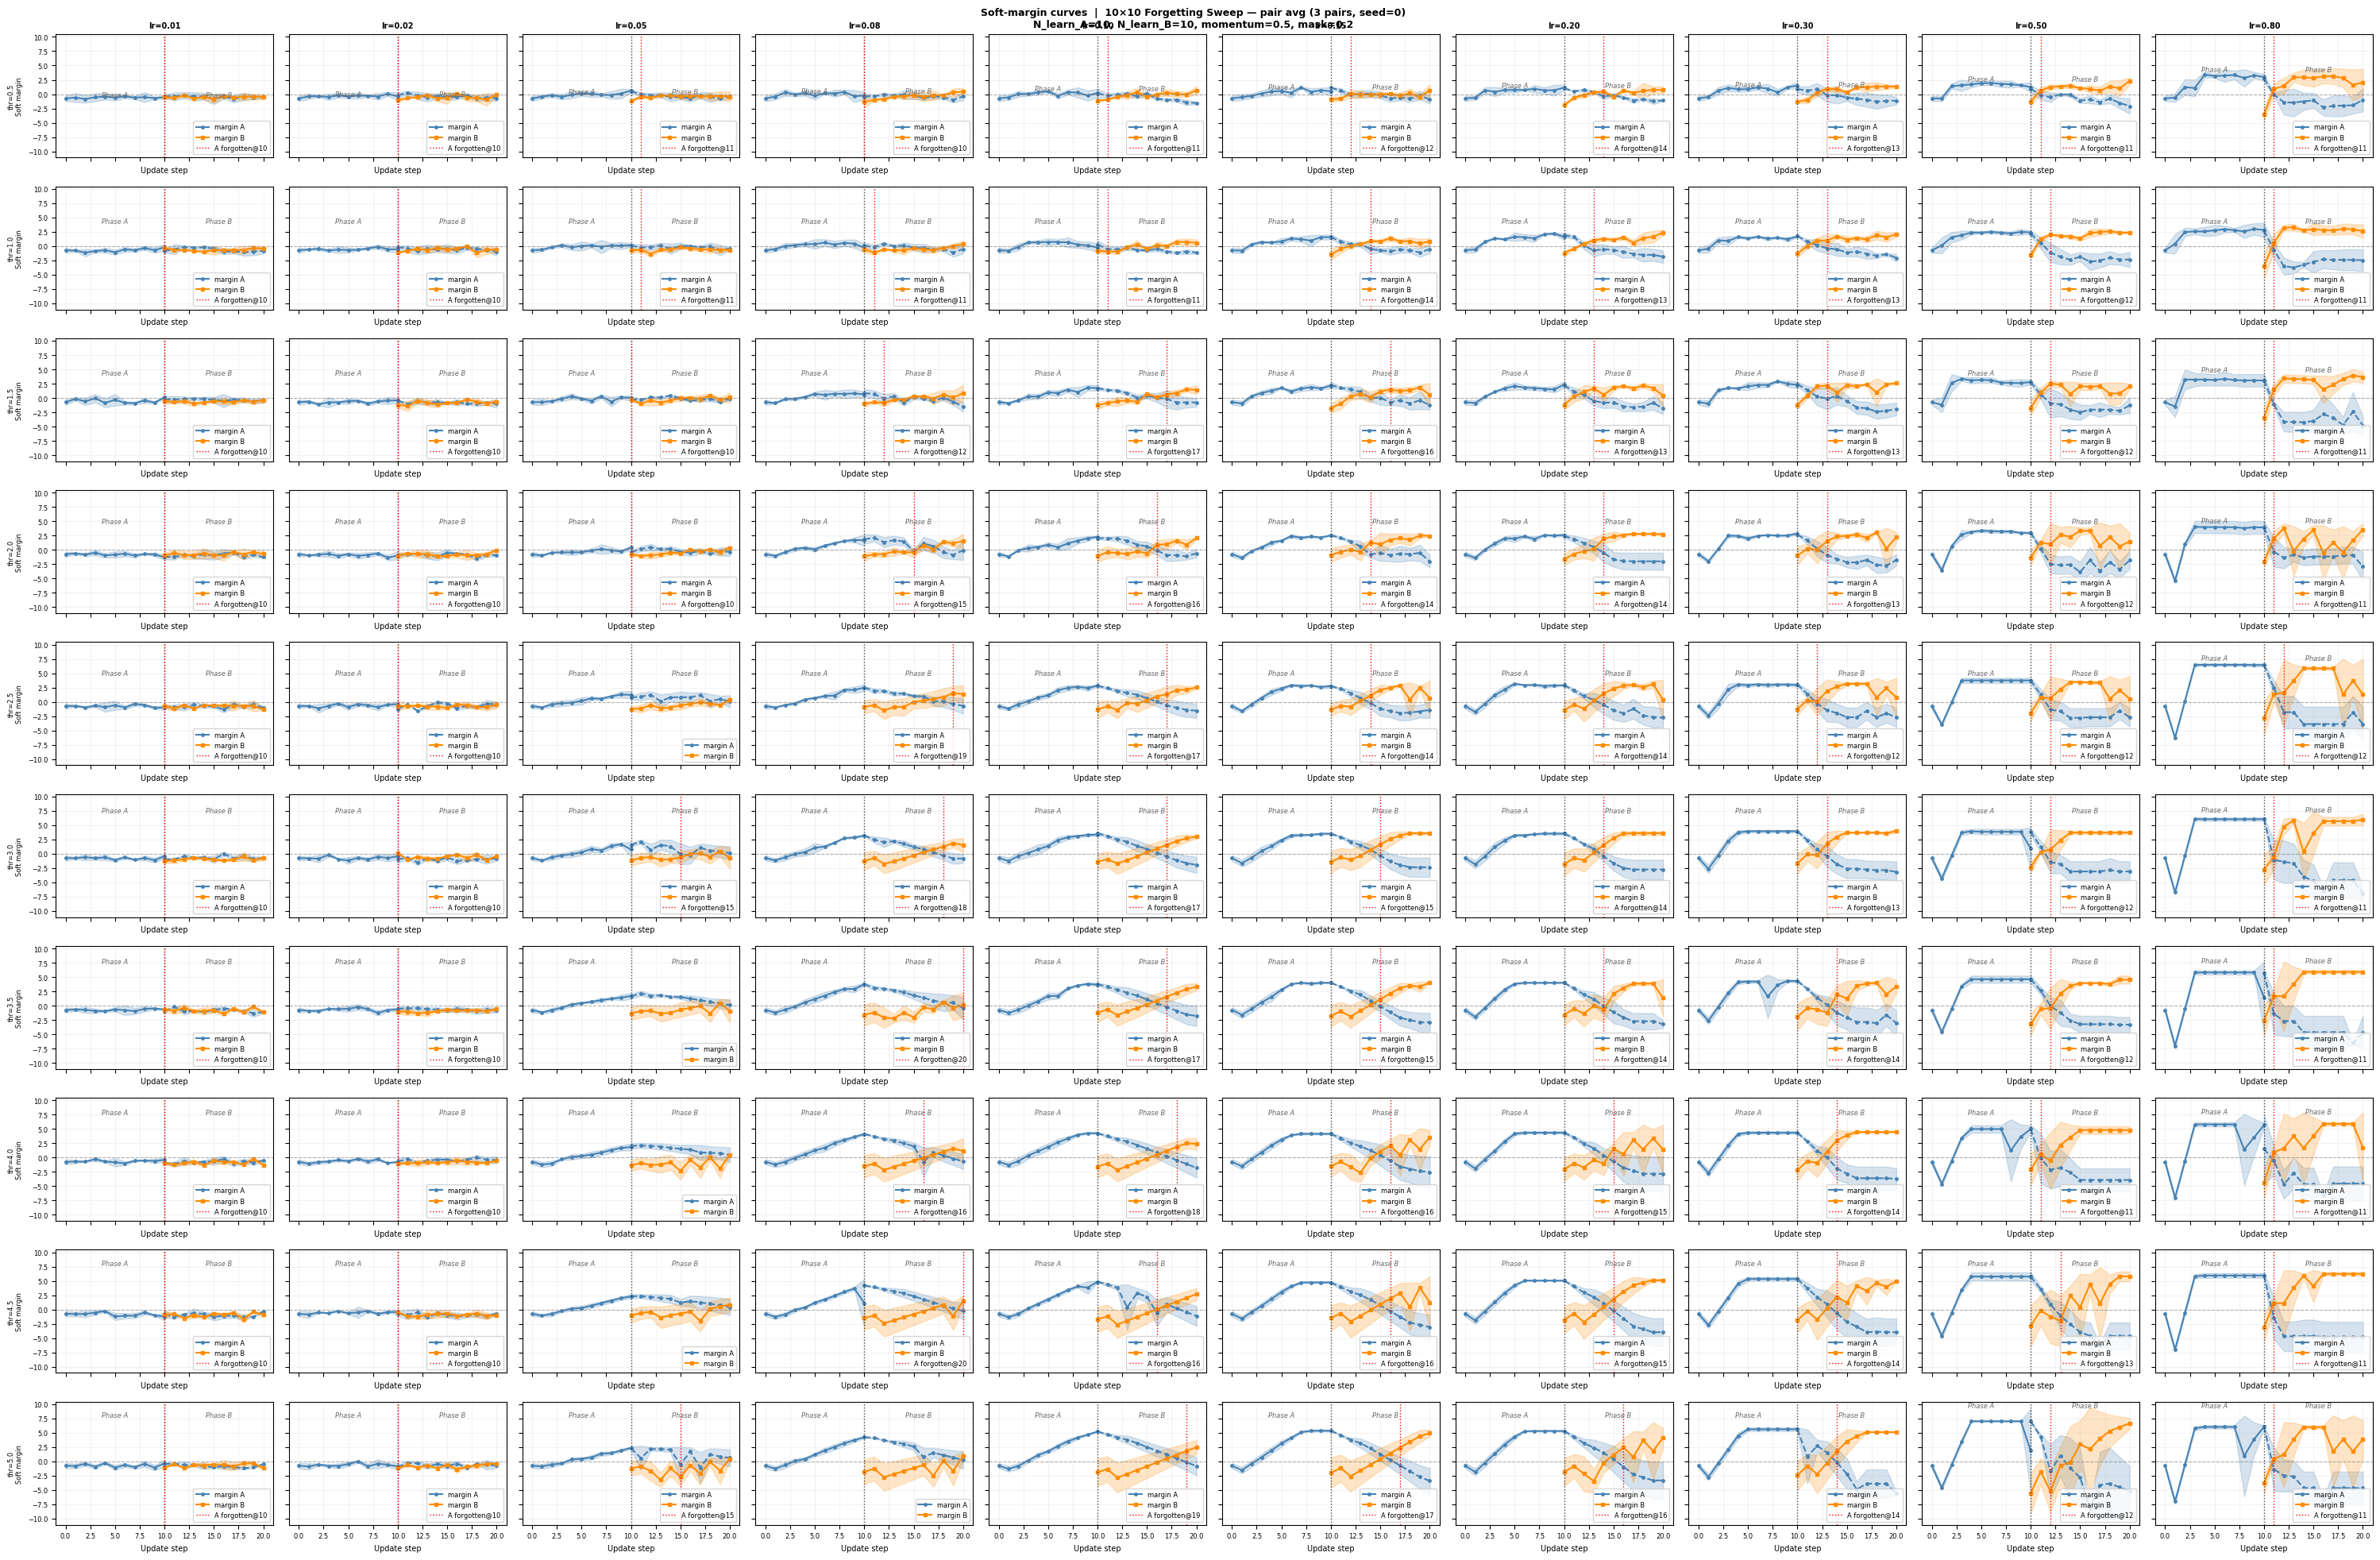

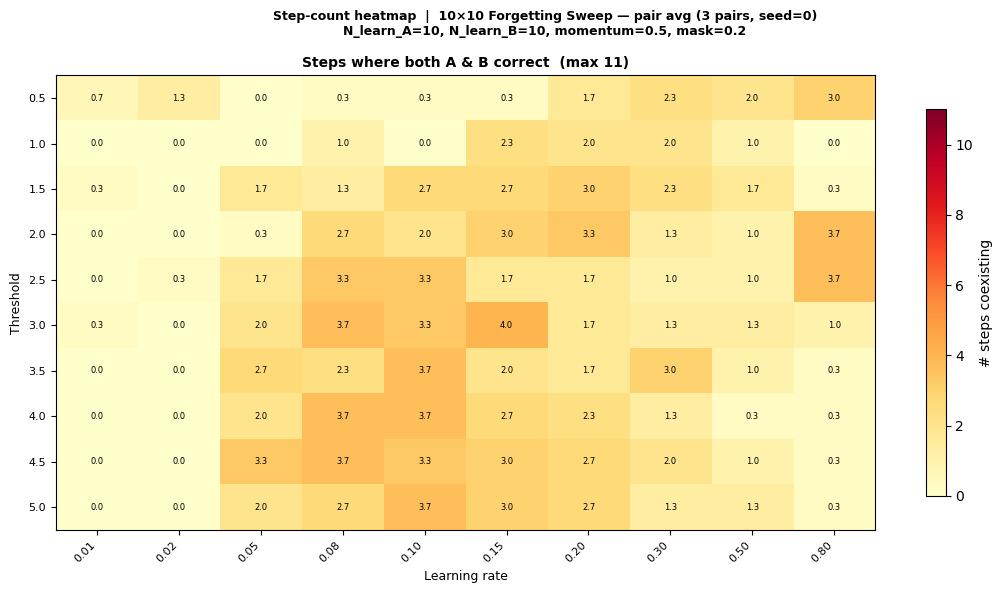

In [35]:

def plot_sweep10(forget_results, step_counts, thresholds, lrs, n_learn_b=N_LEARN_B):
    """Two figures:
    1. 10×10 grid of soft-margin forgetting curves (pair-averaged)
    2. Heatmap of # phase-B steps where both A and B are memorised
    """
    n_thr, n_lr = len(thresholds), len(lrs)
    suptitle = (
        f"10×10 Forgetting Sweep — pair avg ({len(SWEEP10_PAIRS)} pairs, seed={FIXED_SEED})\n"
        f"N_learn_A={N_LEARN_A}, N_learn_B={N_LEARN_B}, momentum={MOMENTUM}, mask={MASK_PROB}"
    )

    # ── Figure 1: 10×10 grid of forgetting curves ──────────────────────
    fig1, axes1 = plt.subplots(
        n_thr, n_lr,
        figsize=(3.0 * n_lr, 2.0 * n_thr),
        sharex=True, sharey="all",
    )
    for r, thr in enumerate(thresholds):
        for c, lr_val in enumerate(lrs):
            ax = axes1[r, c]
            means, stds = forget_results[(thr, lr_val)]
            plot_forgetting(means, stds, threshold=thr, lr=lr_val, ax=ax)
            ax.set_title(f"lr={lr_val:.2f}" if r == 0 else "", fontsize=7, fontweight="bold")
            ax.set_ylabel(f"thr={thr:.1f}\nSoft margin" if c == 0 else "", fontsize=6)
    fig1.suptitle("Soft-margin curves  |  " + suptitle, fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── Figure 2: step-count heatmap ───────────────────────────────────
    lr_labels  = [f"{l:.2f}" for l in lrs]
    thr_labels = [f"{t:.1f}" for t in thresholds]
    ann_fs = max(5, 8 - n_thr // 5)

    mat_cnt = np.zeros((n_thr, n_lr))
    for r, thr in enumerate(thresholds):
        for c, lr_val in enumerate(lrs):
            mat_cnt[r, c] = step_counts[(thr, lr_val)]
    vmax_cnt = max(n_learn_b + 1, int(np.nanmax(mat_cnt)) + 1)

    fig2, ax2 = plt.subplots(figsize=(max(9, 1.1 * n_lr), max(5, 0.6 * n_thr)))
    im = ax2.imshow(mat_cnt, cmap="YlOrRd", vmin=0, vmax=vmax_cnt, aspect="auto")
    ax2.set_xticks(range(n_lr));  ax2.set_xticklabels(lr_labels, rotation=45, ha="right", fontsize=8)
    ax2.set_yticks(range(n_thr)); ax2.set_yticklabels(thr_labels, fontsize=8)
    ax2.set_xlabel("Learning rate", fontsize=9); ax2.set_ylabel("Threshold", fontsize=9)
    ax2.set_title(f"Steps where both A & B correct  (max {n_learn_b + 1})", fontsize=10, fontweight="bold")
    for r in range(n_thr):
        for c in range(n_lr):
            v = mat_cnt[r, c]
            ax2.text(c, r, f"{v:.1f}", ha="center", va="center",
                     fontsize=ann_fs, color="black" if v < 0.6 * vmax_cnt else "white")
    plt.colorbar(im, ax=ax2, shrink=0.85, label="# steps coexisting")
    fig2.suptitle("Step-count heatmap  |  " + suptitle, fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_sweep10(sweep10_forget_results, sweep10_step_counts,
             SWEEP10_THRESHOLDS, SWEEP10_LRS)


In [36]:

# ── 5×5 sweep (low-LR regime) — image-pair averaging only ─────────────
SWEEP5_THRESHOLDS = [0.5, 1.0, 1.7, 2.5, 3.5]
SWEEP5_LRS        = [0.0001, 0.0005, 0.001, 0.005]

# Image pairs for averaging
SWEEP5_PAIRS = [(0,1),(2,3),(4,5)]

n_combos_5 = len(SWEEP5_THRESHOLDS) * len(SWEEP5_LRS)
print(f"5×5 low-LR sweep: {n_combos_5} combos, {len(SWEEP5_PAIRS)} image pairs each")
print(f"  thresholds : {SWEEP5_THRESHOLDS}")
print(f"  lrs        : {SWEEP5_LRS}")
print(f"  pairs      : {SWEEP5_PAIRS}")

print("\nRunning 5×5 low-LR forgetting sweep (pair averaging) …")
sweep5_forget_results, sweep5_scores_S, sweep5_step_counts = run_sweep10_pairs(
    SWEEP5_THRESHOLDS, SWEEP5_LRS, SWEEP5_PAIRS, x, y,
)
print("Done.")


5×5 low-LR sweep: 20 combos, 3 image pairs each
  thresholds : [0.5, 1.0, 1.7, 2.5, 3.5]
  lrs        : [0.0001, 0.0005, 0.001, 0.005]
  pairs      : [(0, 1), (2, 3), (4, 5)]

Running 5×5 low-LR forgetting sweep (pair averaging) …
  thr=0.50 done
  thr=1.00 done
  thr=1.70 done
  thr=2.50 done
  thr=3.50 done
Done.


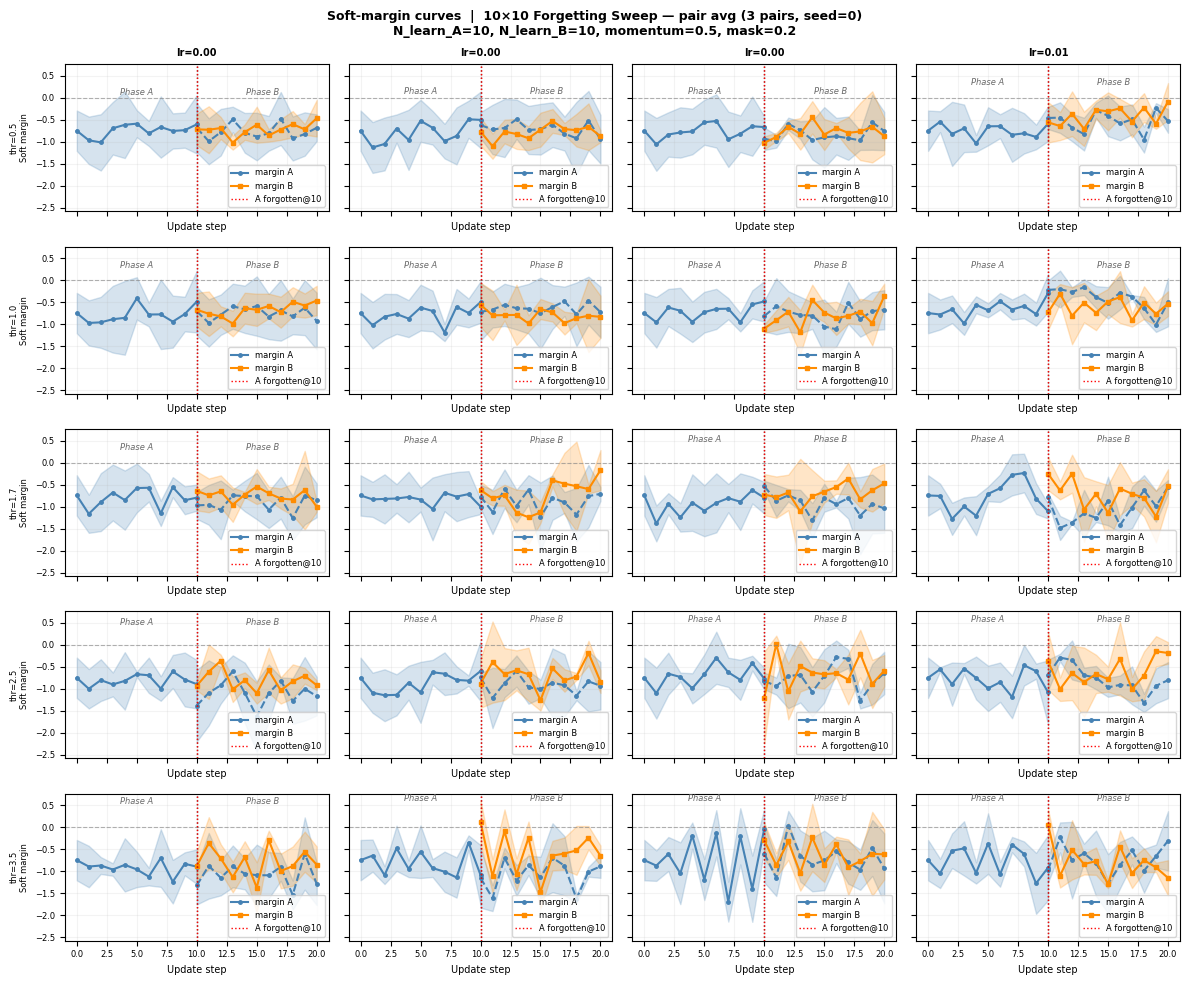

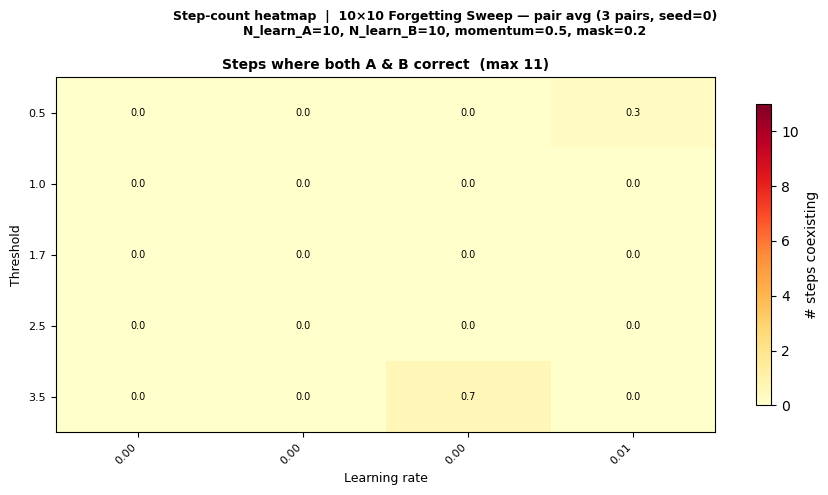

In [37]:

plot_sweep10(sweep5_forget_results, sweep5_step_counts,
             SWEEP5_THRESHOLDS, SWEEP5_LRS)
